In [2]:
### section here is to download technical analysis data from Peihan/Norman.

import yfinance as yf
import pandas as pd
import ta
from google.cloud import bigquery
from datetime import datetime
import json
import os

####Note that the stock_config.json must be in the same directory is your py file

# Load stock config
with open("stock_config.json") as f:
    stock_config = json.load(f)

# Load BigQuery config
with open("bq_config.json") as f:
    bq_config = json.load(f)

##extract ticker values
period = stock_config["period"]
tickers = stock_config["ticker"]

# Extract BigQuery values
project_id = bq_config["project_id"]
dataset_id = bq_config["dataset_id"]
table_id = bq_config["table_id_ta"]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]  # service account private key 


# === SET UP BIGQUERY CLIENT ===
client = bigquery.Client(project=project_id)
table_ref = f"{project_id}.{dataset_id}.{table_id}"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND,
    schema=[
        bigquery.SchemaField("date", "DATE"),
        bigquery.SchemaField("ticker_symbol", "STRING"),
        bigquery.SchemaField("rsi_14", "FLOAT"),
        bigquery.SchemaField("sma_50", "FLOAT"),
        bigquery.SchemaField("ema_50", "FLOAT"),
    ],
)

# === PROCESS EACH TICKER ===
for ticker in tickers:
    try:
        print(f"⏱️ {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} - Downloading and processing: {ticker}")

        df = yf.download(ticker, period=period, auto_adjust=True)
        df.reset_index(inplace=True)

        close_prices = df['Close']
        if isinstance(close_prices, pd.DataFrame) or len(close_prices.shape) > 1:
            close_prices = close_prices.squeeze()

        # Calculate indicators
        df['rsi_14'] = ta.momentum.RSIIndicator(close=close_prices, window=14).rsi()
        df['sma_50'] = ta.trend.SMAIndicator(close=close_prices, window=50).sma_indicator()
        df['ema_50'] = ta.trend.EMAIndicator(close=close_prices, window=50).ema_indicator()

        # Add ticker column
        df['ticker_symbol'] = ticker

        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = ['_'.join(map(str, col)).strip('_') for col in df.columns.values]

        # Select columns and rename for BigQuery
        df_bq = df[['Date', 'ticker_symbol', 'rsi_14', 'sma_50', 'ema_50']].copy()
        df_bq.rename(columns={'Date': 'date'}, inplace=True)

        # Remove rows with missing indicator values
        df_bq.dropna(inplace=True)

        # Upload to BigQuery
        job = client.load_table_from_dataframe(df_bq, table_ref, job_config=job_config)
        job.result()

        print(f"✅ Uploaded {len(df_bq)} rows for {ticker} to {table_ref}.")

    except Exception as e:
        print(f"❌ Error processing {ticker}: {e}")

print("🎉 All tickers uploaded successfully.")

⏱️ 2025-06-18 16:52:48 - Downloading and processing: AAPL


[*********************100%***********************]  1 of 1 completed


✅ Uploaded 1460 rows for AAPL to deft-beacon-354008.stock_analysis.techincal_indicator.
⏱️ 2025-06-18 16:52:52 - Downloading and processing: CAT


[*********************100%***********************]  1 of 1 completed


✅ Uploaded 1460 rows for CAT to deft-beacon-354008.stock_analysis.techincal_indicator.
⏱️ 2025-06-18 16:52:56 - Downloading and processing: BA


...

[*********************100%***********************]  1 of 1 completed


✅ Uploaded 1460 rows for XLU to deft-beacon-354008.stock_analysis.techincal_indicator.
⏱️ 2025-06-18 16:53:44 - Downloading and processing: XLF


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ Uploaded 1460 rows for XLF to deft-beacon-354008.stock_analysis.techincal_indicator.
⏱️ 2025-06-18 16:53:49 - Downloading and processing: XLRE


✅ Uploaded 1460 rows for XLRE to deft-beacon-354008.stock_analysis.techincal_indicator.
🎉 All tickers uploaded successfully.


In [3]:
### section here is to download yfinance jacob's code this is usable. Includes Peihan's orginal code.
import yfinance as yf
import pandas as pd
from google.cloud import bigquery
import json
import os

####Note that the stock_config.json must be in the same directory is your py file

# Load stock config
with open("stock_config.json") as f:
    stock_config = json.load(f)

# Load BigQuery config
with open("bq_config.json") as f:
    bq_config = json.load(f)


##extract ticker values
ticker_symbols = stock_config["ticker"] 
period = stock_config["period"]



# Extract BigQuery values
project_id = bq_config["project_id"]
dataset_id = bq_config["dataset_id"]
table_id = bq_config["table_id"]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]  # service account private key 


# Collect data for each ticker
all_data = []

for symbol in ticker_symbols:
    df = yf.Ticker(symbol).history(period=period)
    df["ticker_symbol"] = symbol  # Add a column to identify the ticker
    all_data.append(df)

# Combine all into one DataFrame
combined_df = pd.concat(all_data)

# Optional: Reset index if needed
combined_df = combined_df.reset_index()

combined_df = combined_df.rename(columns={
    "Open": "open_price",
    "Close": "close_price",
    "High": "high_price",
    "Low": "low_price",
    "Volume": "volume_traded",
    "Dividends":"dividend",
    "Stock Splits":"stock_splits",
    "Date":"date"
})

########## Peihan code section################################33
##df = yf.download(ticker_symbols, period=period)
##df.columns = ['{}_{}'.format(col[0], col[1]) for col in df.columns]  # flatten columns
##df = df.reset_index()

##df = (
##    pd.melt(df, id_vars='Date', var_name='Price_Ticker', value_name='Value')
##      .assign(Price_Type=lambda x: x.Price_Ticker.str.split('_').str[0],
##              Ticker=lambda x: x.Price_Ticker.str.split('_').str[1])
##      .drop(columns='Price_Ticker')
##      .pivot_table(index=['Date', 'Ticker'], columns='Price_Type', values='Value')
##      .reset_index()
##)


##### Perhan Code Section ########################################


# 3. Initialize BigQuery client
client = bigquery.Client(project=project_id)

# 4. Load data into BigQuery
job_config = bigquery.LoadJobConfig(
    ## section here is set to over ride the data. Using append complicates the code
    write_disposition="WRITE_TRUNCATE",  # or WRITE_TRUNCATE or # "Write_Append"
    autodetect=True,
    source_format=bigquery.SourceFormat.PARQUET
)

# Load DataFrame to BigQuery
job = client.load_table_from_dataframe(
    combined_df, f"{project_id}.{dataset_id}.{table_id}", job_config=job_config
)
job.result()  # Wait for completion  # or use .history(start=..., end=...

LoadJob<project=deft-beacon-354008, location=US, id=55b603ef-f7d9-43b4-aac7-3fadf0ecce60>

In [2]:
### Section here is to download fred data. Use the fred_config json to configure what you wish to pull out. 

import pandas_datareader.data as web
import datetime
from dateutil.relativedelta import relativedelta
import yfinance as yf
import pandas as pd
from google.cloud import bigquery
import json
import os


# Function to compute start_date based on period no longer need to specify end and 
def get_date_range_from_period(period_str):
    today = datetime.date.today()
    end_date = today

    if period_str.endswith("d"):
        delta = datetime.timedelta(days=int(period_str[:-1]))
    elif period_str.endswith("mo"):
        delta = relativedelta(months=int(period_str[:-2]))
    elif period_str.endswith("y"):
        delta = relativedelta(years=int(period_str[:-1]))
    else:
        raise ValueError(f"Invalid period: {period_str}. Use formats like '1mo', '3y', '7d'.")

    start_date = end_date - delta
    return datetime.datetime.combine(start_date, datetime.time.min), datetime.datetime.combine(end_date, datetime.time.min)

# Load configuration
with open("fred_config.json") as f:
    config = json.load(f)

with open("bq_config.json") as f:
    bq_config = json.load(f)




# Extract BigQuery values
project_id = bq_config["project_id"]
dataset_id = bq_config["dataset_id"]
table_id = bq_config["table_id_fred"]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]

# Load series info
series_config = config["series"]



# Compute date range from period
period = config.get("period", "1y")  # default to 1 year if not specified
start_date, end_date = get_date_range_from_period(period)



# Download and combine data
econ_data = pd.DataFrame()

for series_code, series_name in series_config.items():
    print(f"Downloading {series_name} ({series_code})...")
    data = web.DataReader(series_code, 'fred', start_date, end_date)
    data.columns = [series_name]
    econ_data = data if econ_data.empty else econ_data.join(data, how='outer')



econ_data.index.name = "date"


# 3. Initialize BigQuery client
client = bigquery.Client(project=project_id)

# 4. Load data into BigQuery
job_config = bigquery.LoadJobConfig(
    ## section here is set to over ride the data. Using append complicates the code
    write_disposition="WRITE_TRUNCATE",  # or WRITE_TRUNCATE or # "Write_Append"
    autodetect=True,
    source_format=bigquery.SourceFormat.PARQUET
)

# Load DataFrame to BigQuery
job = client.load_table_from_dataframe(
    econ_data, f"{project_id}.{dataset_id}.{table_id}", job_config=job_config
)
job.result()  # Wait for completion  # or use .history(start=..., end=...

LoadJob<project=deft-beacon-354008, location=US, id=cd919d30-8bcc-47e3-bbfa-d52cc0c8787c>

In [2]:
#### this code pulls all yfinance stock info which includes dividends and stuff sector

import pandas_datareader.data as web
import datetime
from dateutil.relativedelta import relativedelta
import yfinance as yf
import pandas as pd
from google.cloud import bigquery
import json
import os


# Load configuration
with open("stock_config.json") as f:
    config = json.load(f)

with open("bq_config.json") as f:
    bq_config = json.load(f)


tickers = config.get("ticker", [])


# Extract BigQuery values
project_id = bq_config["project_id"]
dataset_id = bq_config["dataset_id"]
table_id = bq_config["table_id_stock_info"]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]  # service account private key 



# List to collect info dicts
data = []

# Loop through each ticker
for symbol in tickers:
    try:
        ticker = yf.Ticker(symbol)
        info = ticker.get_info()

        if info:
            # Extract only selected fields
            entry = {
                "ticker_symbol": symbol,
                "company_name": info.get("longName"),
                "company_description": info.get("longBusinessSummary"),
                "country":info.get("country"),
                "sector": info.get("sector"),
                "industry": info.get("industry"),
                "market_cap": info.get("marketCap"),
                "country": info.get("country"),
                "trailing_pe":info.get("trailingPE"),
                "forward_pe":info.get("forwardPE"),
                "trailing_EPS": info.get("trailingEps"),
                "forward_EPS":info.get("forwardEps"),    
                "dividendYield": info.get("dividendYield"),
                "book_value_per_share": info.get('bookValue')  



            }
            data.append(entry)
        else:
            print(f"No data found for {symbol}")
    except Exception as e:
        print(f"Error retrieving {symbol}: {e}")

# Combine into one DataFrame
df_stock_info = pd.DataFrame(data)

# Combine into one DataFrame
df_stock_info = pd.DataFrame(data)

# 3. Initialize BigQuery client
client = bigquery.Client(project=project_id)

# 4. Load data into BigQuery
job_config = bigquery.LoadJobConfig(
    ## section here is set to over ride the data. Using append complicates the code
    write_disposition="WRITE_TRUNCATE",  # or WRITE_TRUNCATE or # "Write_Append"
    autodetect=True,
    source_format=bigquery.SourceFormat.PARQUET
)

# Load DataFrame to BigQuery
job = client.load_table_from_dataframe(
    df_stock_info, f"{project_id}.{dataset_id}.{table_id}", job_config=job_config
)
job.result()  # Wait for completion  # or use .history(start=..., end=...

LoadJob<project=deft-beacon-354008, location=US, id=56a051a3-e1c9-48cf-8bd1-73e039f9d778>

☀️☀️☀️☀️☀️☀️This is the Final/actual code for Running my datasource from Big Query. ☀️☀️☀️☀️☀️☀️


📊 Key Metrics:
- Sector: Technology
- P/E Ratio: 37.17 (Sector Avg: 38.22)
- P/B Ratio: 11.04
- Dividend Yield: 0.00%
- RSI: 72.22


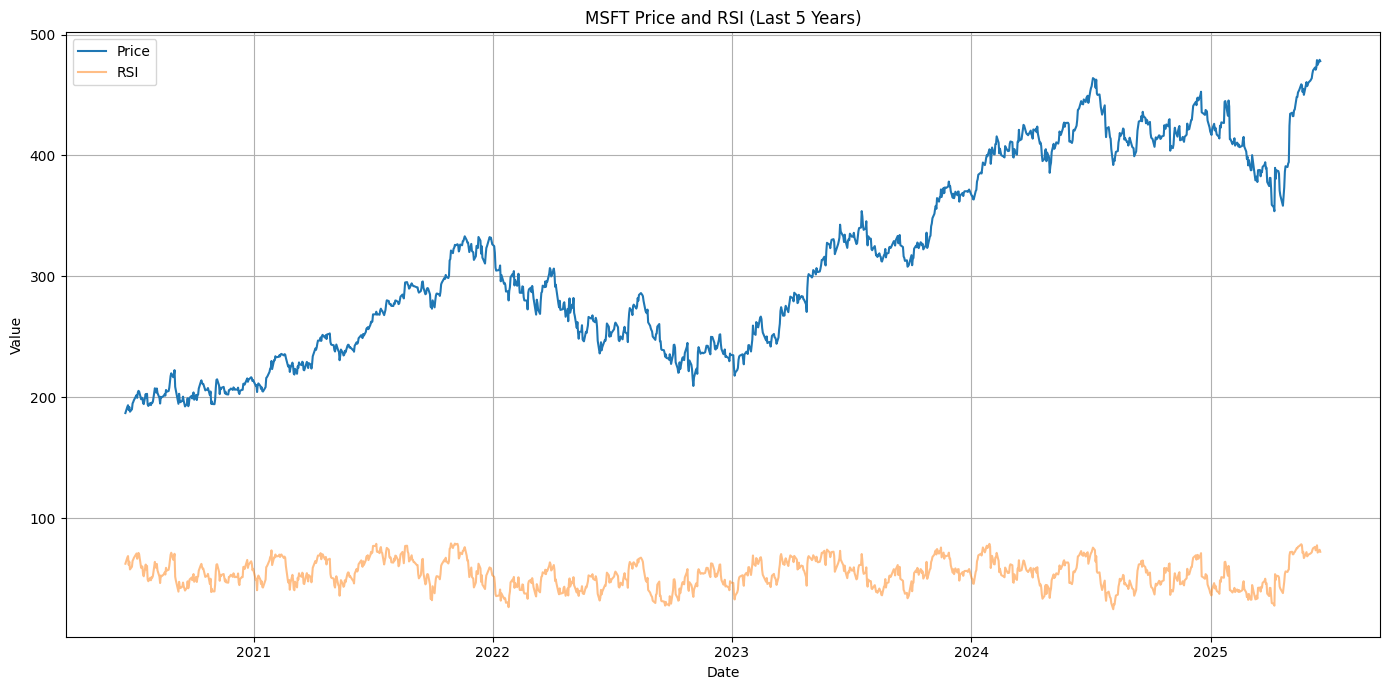

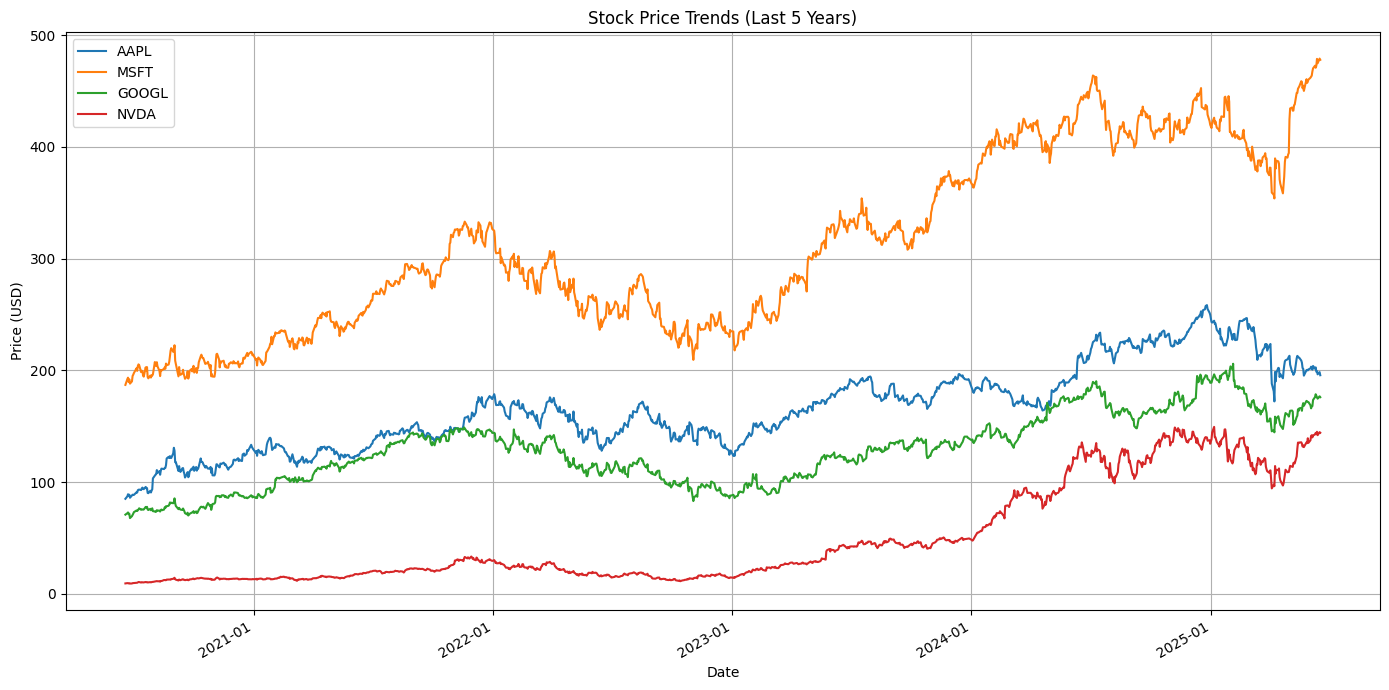

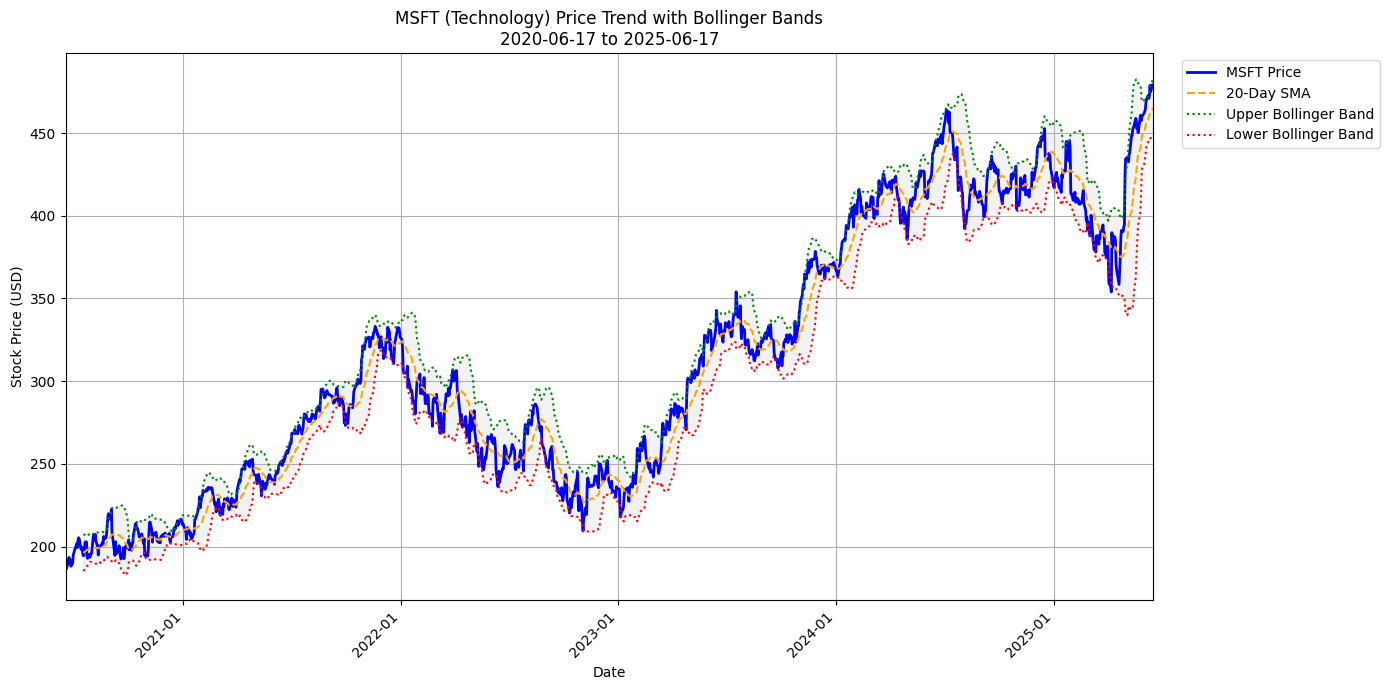

Plotting data from 2020-06-17 to 2025-06-17
Price range: $186.97 to $479.14

=== Detailed Analysis: MSFT (Technology) ===
Current Price: 478.04
P/E Ratio: 37.17
Dividend Yield: 0.00%
RSI: 72.22
50-Day SMA: 429.82

Valuation Assessment:
- P/E ratio is moderate, compare to sector average
- No dividend yield
- RSI above 70 indicates overbought condition
- Price above 50-Day SMA (positive trend)

Bollinger Bands Interpretation:
- Price is within Bollinger Bands: Neutral range

Recommendation:

Summary:
MSFT trades at a relatively high P/E ratio, which may indicate growth expectations are already priced in., does not offer a dividend, which may reduce its income appeal., is currently overbought based on RSI, suggesting caution., is trading above its 50-day moving average, indicating positive price momentum., is trading within its Bollinger Bands, indicating a balanced technical position.
Consider further analysis of:
- Sector comparison metrics
- Recent earnings reports
- Company fundamenta

In [9]:
# Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
import json
import os
import datetime

# === BigQuery Setup ===
with open("bq_config.json") as f:
    bq_config = json.load(f)

project_id = bq_config["project_id"]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = bq_config["key"]
client = bigquery.Client(project=project_id)

# Configuration
tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
years_of_history = 5

# Step 1: Load Stock Data from BigQuery
def get_stock_data(tickers):
    query = f"""
    SELECT 
        f.date,
        f.ticker_symbol,
        f.close_price,
        f.rsi_14,
        f.trailing_pe,
        f.trailing_eps,
        f.dividend,
        f.market_cap,
        f.sma_50,
        f.book_value_per_share,
        i.sector,
        i.industry
    FROM 
        `{project_id}.stock_analysis.fact_security` f
    JOIN 
        `{project_id}.stock_analysis.dim_info` i
        ON f.ticker_symbol = i.ticker_symbol
    WHERE 
        f.date >= DATE_SUB(CURRENT_DATE(), INTERVAL {years_of_history} YEAR)
        AND f.ticker_symbol IN UNNEST(@tickers)
    ORDER BY 
        f.ticker_symbol, f.date
    """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("tickers", "STRING", tickers)
        ]
    )
    
    df = client.query(query, job_config=job_config).to_dataframe()
    df['date'] = pd.to_datetime(df['date'])
    return df

stock_df = get_stock_data(tickers)

# Step 2: Prepare Stock Data
stock_data = {}
for ticker in tickers:
    ticker_data = stock_df[stock_df['ticker_symbol'] == ticker].sort_values('date')
    if ticker_data.empty:
        print(f"No data found for {ticker}")
        continue
    
    latest = ticker_data.iloc[-1]
    sector_avg_pe = stock_df[stock_df['sector'] == latest['sector']]['trailing_pe'].mean()
    
    stock_data[ticker] = {
        'history': ticker_data,
        'pe_ratio': latest['trailing_pe'],
        'pb_ratio': latest['close_price'] / latest['book_value_per_share'] if latest['book_value_per_share'] > 0 else np.nan,
        'dividend_yield': latest['dividend'] / latest['close_price'] * 100 if latest['dividend'] > 0 else 0,
        'sector': latest['sector'],
        'rsi': latest['rsi_14'],
        'sma_50': latest['sma_50']
    }

# Step 3: Create Valuation DataFrame
valuation_df = pd.DataFrame({
    'Ticker': [],
    'Sector': [],
    'P/E Ratio': [],
    'P/B Ratio': [],
    'Dividend Yield': [],
    'Latest RSI': [],
    'sma_50': []
})

for ticker, data in stock_data.items():
    valuation_df = pd.concat([valuation_df, pd.DataFrame({
        'Ticker': [ticker],
        'Sector': [data['sector']],
        'P/E Ratio': [data['pe_ratio']],
        'P/B Ratio': [data['pb_ratio']],
        'Dividend Yield': [data['dividend_yield']],
        'Latest RSI': [data['rsi']],
        'sma_50': [data['sma_50']]
    })], ignore_index=True)

# Step 4: Multi-Factor Scoring
factors = ['P/E Ratio', 'P/B Ratio', 'Dividend Yield', 'Latest RSI']
for factor in factors:
    valuation_df[f'{factor}_z'] = (
        (valuation_df[factor] - valuation_df[factor].mean()) / 
        valuation_df[factor].std()
    )

valuation_df['Multi-Factor Score'] = (
    -valuation_df['P/E Ratio_z'] + 
    -valuation_df['P/B Ratio_z'] + 
    valuation_df['Dividend Yield_z'] + 
    -valuation_df['Latest RSI_z']
)
valuation_df = valuation_df.sort_values('Multi-Factor Score', ascending=False)



# Step 7: Detailed Stock Evaluation
def evaluate_stock(stock_info):
    evaluation = {
        'Undervalued': False,
        'Reasons': [],
        'Cautions': []
    }
    
    # P/E Ratio Analysis
    sector_avg_pe = valuation_df[valuation_df['Sector'] == stock_info['sector']]['P/E Ratio'].mean()
    if stock_info['pe_ratio'] < sector_avg_pe * 0.8:  # 20% below sector average
        evaluation['Reasons'].append(f"P/E ratio of {stock_info['pe_ratio']:.2f} is below sector average ({sector_avg_pe:.2f})")
        evaluation['Undervalued'] = True
    else:
        evaluation['Cautions'].append(f"P/E ratio of {stock_info['pe_ratio']:.2f} is near or above sector average ({sector_avg_pe:.2f})")
    
    # P/B Ratio Analysis
    if stock_info['pb_ratio'] < 3:  # Conservative threshold
        evaluation['Reasons'].append(f"P/B ratio of {stock_info['pb_ratio']:.2f} suggests reasonable valuation")
        evaluation['Undervalued'] = True
    else:
        evaluation['Cautions'].append(f"P/B ratio of {stock_info['pb_ratio']:.2f} may indicate overvaluation")
    
    # Dividend Yield Analysis
    if stock_info['dividend_yield'] > 2.5:  # Attractive yield threshold
        evaluation['Reasons'].append(f"Attractive dividend yield of {stock_info['dividend_yield']:.2f}%")
        evaluation['Undervalued'] = True
    elif stock_info['dividend_yield'] > 0:
        evaluation['Cautions'].append(f"Modest dividend yield of {stock_info['dividend_yield']:.2f}%")
    
    # RSI Analysis
    if stock_info['rsi'] < 40:
        evaluation['Reasons'].append(f"RSI of {stock_info['rsi']:.2f} suggests potential oversold condition")
        evaluation['Undervalued'] = True
    elif stock_info['rsi'] > 60:
        evaluation['Cautions'].append(f"RSI of {stock_info['rsi']:.2f} may indicate overbought condition")
    
    return evaluation

# Evaluate top stock
top_stock_ticker = "MSFT"
top_stock_info = stock_data[top_stock_ticker]
evaluation = evaluate_stock(top_stock_info)



# Show stock metrics
print("\n📊 Key Metrics:")
print(f"- Sector: {top_stock_info['sector']}")
print(f"- P/E Ratio: {top_stock_info['pe_ratio']:.2f} (Sector Avg: {valuation_df[valuation_df['Sector'] == top_stock_info['sector']]['P/E Ratio'].mean():.2f})")
print(f"- P/B Ratio: {top_stock_info['pb_ratio']:.2f}")
print(f"- Dividend Yield: {top_stock_info['dividend_yield']:.2f}%")
print(f"- RSI: {top_stock_info['rsi']:.2f}")

# Plot technicals for top stock
plt.figure(figsize=(14, 7))
plt.plot(stock_data[top_stock_ticker]['history']['date'], 
         stock_data[top_stock_ticker]['history']['close_price'], 
         label='Price')
plt.plot(stock_data[top_stock_ticker]['history']['date'], 
         stock_data[top_stock_ticker]['history']['rsi_14'], 
         label='RSI', alpha=0.5)
plt.title(f"{top_stock_ticker} Price and RSI (Last 5 Years)")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Combined Stock Price Trend for All Tech Stocks
stock_df['date'] = pd.to_datetime(stock_df['date'])
import matplotlib.dates as mdates

plt.figure(figsize=(14, 7))

for ticker, data in stock_data.items():
    plt.plot(data['history']['date'], data['history']['close_price'], label=ticker)

plt.title('Stock Price Trends (Last 5 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Show Year-Month
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Major ticks yearly
plt.gcf().autofmt_xdate()  # Rotate dates for readability

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 9: Example Stock Deep Dive (with Bollinger Bands)
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd

if not valuation_df.empty:
    example_stock = 'MSFT'
    example_sector = valuation_df[valuation_df['Ticker'] == example_stock]['Sector'].values[0]
    example_data = stock_data.get(example_stock, {})

    if example_data and not example_data['history'].empty:
        # Prepare the data - use the correct date column
        history = example_data['history'].copy()
        
        # Ensure we're using the correct date column and set it as index
        if 'date' in history.columns:
            history = history.set_index('date')
        history.index = pd.to_datetime(history.index)
        
        # Sort by date and filter for last 5 years
        history = history.sort_index()
        end_date = history.index.max()
        start_date = end_date - pd.DateOffset(years=5)
        history = history.loc[start_date:end_date]

        # Calculate Bollinger Bands with correct column names
        history['20d_SMA'] = history['close_price'].rolling(window=20).mean()
        history['20d_STD'] = history['close_price'].rolling(window=20).std()
        history['Upper_Band'] = history['20d_SMA'] + 2 * history['20d_STD']
        history['Lower_Band'] = history['20d_SMA'] - 2 * history['20d_STD']

        # Create plot with proper date handling
        plt.figure(figsize=(14, 7))
        
        # Plot using the correct price column
        plt.plot(history.index, history['close_price'], label=f'{example_stock} Price', 
                linewidth=2, color='blue')
        plt.plot(history.index, history['20d_SMA'], label='20-Day SMA', 
                linestyle='--', color='orange')
        plt.plot(history.index, history['Upper_Band'], label='Upper Bollinger Band', 
                linestyle=':', color='green')
        plt.plot(history.index, history['Lower_Band'], label='Lower Bollinger Band', 
                linestyle=':', color='red')
        plt.fill_between(history.index, history['Upper_Band'], history['Lower_Band'], 
                       color='grey', alpha=0.1)

        # Format x-axis
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45, ha='right')
        
        # Set proper date range
        ax.set_xlim([start_date, end_date])
        
        # Auto-scale y-axis to show full price range
        plt.autoscale(enable=True, axis='y')
        
        # Add labels and title
        plt.title(f'{example_stock} ({example_sector}) Price Trend with Bollinger Bands\n{start_date.date()} to {end_date.date()}')
        plt.xlabel('Date')
        plt.ylabel('Stock Price (USD)')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Print the actual date range being used
        print(f"Plotting data from {start_date.date()} to {end_date.date()}")
        print(f"Price range: ${history['close_price'].min():.2f} to ${history['close_price'].max():.2f}")

     

        # Display key metrics
        example_pe = valuation_df[valuation_df['Ticker'] == example_stock]['P/E Ratio'].values[0]
        example_dividend = valuation_df[valuation_df['Ticker'] == example_stock]['Dividend Yield'].values[0]
        example_rsi = valuation_df[valuation_df['Ticker'] == example_stock]['Latest RSI'].values[0]
        example_sma = valuation_df[valuation_df['Ticker'] == example_stock]['sma_50'].values[0]

        print(f"\n=== Detailed Analysis: {example_stock} ({example_sector}) ===")
        print(f"Current Price: {history['close_price'].iloc[-1]:.2f}")
        print(f"P/E Ratio: {example_pe:.2f}")
        print(f"Dividend Yield: {example_dividend:.2f}%")
        print(f"RSI: {example_rsi:.2f}")
        print(f"50-Day SMA: {example_sma:.2f}")

        print("\nValuation Assessment:")
        if example_pe < 15:
            print("- P/E ratio below 15 suggests potentially undervalued")
        else:
            print("- P/E ratio is moderate, compare to sector average")

        if example_dividend > 2.5:
            print("- Attractive dividend yield above 2.5%")
        elif example_dividend > 0:
            print("- Modest dividend yield present")
        else:
            print("- No dividend yield")

        if example_rsi < 40:
            print("- RSI below 30 indicates oversold condition")
        elif example_rsi > 60:
            print("- RSI above 70 indicates overbought condition")
        else:
            print("- RSI in neutral range")

        current_price = history['close_price'].iloc[-1]
        if 'sma_50' in history.columns:
            if current_price > history['sma_50'].iloc[-1]:
                print("- Price above 50-Day SMA (positive trend)")
            else:
                print("- Price below 50-Day SMA (caution advised)")

        print("\nBollinger Bands Interpretation:")
        if current_price < history['Lower_Band'].iloc[-1]:
            print("- Price is below the lower Bollinger Band: Possible oversold signal")
        elif current_price > history['Upper_Band'].iloc[-1]:
            print("- Price is above the upper Bollinger Band: Possible overbought signal")
        else:
            print("- Price is within Bollinger Bands: Neutral range")

        print("\nRecommendation:")
        # Generate Word Summary Based on Key Metrics
        summary_points = []

        # Valuation based on P/E Ratio
        if example_pe < 15:
            summary_points.append("trades at a low P/E ratio, suggesting potential undervaluation compared to peers.")
        elif example_pe < 25:
            summary_points.append("has a reasonable P/E ratio, but further sector comparison is recommended.")
        else:
            summary_points.append("trades at a relatively high P/E ratio, which may indicate growth expectations are already priced in.")

        # Dividend Yield
        if example_dividend > 2.5:
            summary_points.append("offers an attractive dividend yield, enhancing its value appeal.")
        elif example_dividend > 0:
            summary_points.append("provides a modest dividend yield.")
        else:
            summary_points.append("does not offer a dividend, which may reduce its income appeal.")

        # RSI Signal
        if example_rsi < 30:
            summary_points.append("is currently oversold based on RSI, indicating a potential buying opportunity.")
        elif example_rsi > 70:
            summary_points.append("is currently overbought based on RSI, suggesting caution.")
        else:
            summary_points.append("is trading within a neutral RSI range.")

        # Price Position vs SMA
        if current_price < example_sma:
            summary_points.append("is trading below its 50-day moving average, which may suggest near-term weakness or undervaluation.")
        else:
            summary_points.append("is trading above its 50-day moving average, indicating positive price momentum.")

        # Bollinger Bands
        if current_price < history['Lower_Band'].iloc[-1]:
            summary_points.append("is trading below the lower Bollinger Band, indicating potential oversold conditions.")
        elif current_price > history['Upper_Band'].iloc[-1]:
            summary_points.append("is trading above the upper Bollinger Band, indicating potential overbought conditions.")
        else:
            summary_points.append("is trading within its Bollinger Bands, indicating a balanced technical position.")

        # Final Summary Output
        print("\nSummary:")
        print(f"{example_stock} {', '.join(summary_points)}")

        # print("This stock shows several characteristics of potential undervaluation.")
        print("Consider further analysis of:")
        print("- Sector comparison metrics")
        print("- Recent earnings reports")
        print("- Company fundamentals")
        print("- Macroeconomic conditions affecting this sector")
    else:
        print(f"\nNo data available for detailed analysis of {example_stock}")
else:
    print("\nNo stocks available for detailed analysis")

# Display evaluation
print("\n" + "="*50)
print(f"=== Detailed Evaluation: {top_stock_ticker} ===")
print("="*50)

if evaluation['Undervalued']:
    print("\n🔍 This stock appears UNDERVALUED based on:")
    for reason in evaluation['Reasons']:
        print(f"✓ {reason}")
else:
    print("\n⚠️ This stock does not appear significantly undervalued:")

if evaluation['Cautions']:
    print("\n⚠️ Suggesstion:")
    for caution in evaluation['Cautions']:
        print(f"• {caution}")